### The Data Analysis Workshop
This is a book aims to Solve business problems with state-of-the-art data analysis models,
developing expert data analysis skills along the way.                                                                                                       
**by** Gururajan Govindan, Shubhangi Hora, and Konstantin Palagachev

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
%matplotlib inline

# DATA PREPROCESSING
### Mapping columns
##### According to the description of the original data, provided in the Readme.txt file, we can split the columns into three main groups:
1. **temporal** features: This contains information about the time at which the record was registered. This group contains the dteday, season, yr, mnth hr, holiday, weekday, and workingday columns.
2. **Weather related features**: This contains information about the weather conditions. The weathersit, temp, atemp, hum, and windspeed columns 
are included in this group.
3. **record related features**: This contains information about the number of records for the specific hour and date. This group includes the casual, 
registered, and cnt columns.


In [ ]:
df = pd.read_csv('https://raw.githubusercontent.com/'\
                          'PacktWorkshops/'\
'The-Data-Analysis-Workshop/'\
'master/Chapter01/data/hour.csv')  # Reading the Dataset.
df.head()  # printing the first 5 rows of the dataset.

In [ ]:
print('the Shape is {}'.format(df.shape), '\n\n')  #  the shape of the data 
print(df.info())  # Some info about the columns in the dataset.

In [ ]:
# How many null values in the dataset?
df.isnull().sum()

In [ ]:
# Description of the numerical columns.
df.select_dtypes(exclude='object').describe()

- The seasons column contains values from 1 to 4, which encode, respectively, **the Winter, Spring, Summer, and Fall seasons.** 
- The yr column contains the values 0 and 1 representing **2011 and 2012**,
- while the weekday column contains values from 0 to 6, with each one representing a day of the week **(0: Sunday, 1: Monday, through to 6: Saturday)**. 
- Furthermore, we scale the hum column to values between 0 and 100 (as it represents the humidity percentage),
and the windspeed column to values between 0 and 67 (as those are the registered minimum and maximum wind speed)

### For our Analysis we need to map all those columns so we can get the best of the visualization.

In [ ]:
# create a copy of the original data
preprocessed_data = df.copy()

# tranform seasons
seasons_mapping = {1: 'winter', 2: 'spring', 3: 'summer', 4: 'fall'}
preprocessed_data['season'] = preprocessed_data['season'].map(seasons_mapping)

# transform yr
yr_mapping = {0: 2011, 1: 2012}
preprocessed_data['yr'] = preprocessed_data['yr'].map(yr_mapping)

# transform weekday
weekday_mapping = {0: 'Sunday', 1: 'Monday', 2: 'Tuesday', 3: 'Wednesday', 4: 'Thursday', 5: 'Friday', 6: 'Saturday'}
preprocessed_data['weekday'] = preprocessed_data['weekday'].map(weekday_mapping)

# transform weathersit
weather_mapping = {1: 'clear', 2: 'cloudy', 3: 'light_rain_snow', 4: 'heavy_rain_snow'}
preprocessed_data['weathersit'] = preprocessed_data['weathersit'].map(weather_mapping) 

# transorm hum and windspeed
preprocessed_data['hum'] = preprocessed_data['hum'] * 100
preprocessed_data['windspeed'] = preprocessed_data['windspeed'] * 67

# visualize preprocessed columns
cols = ['season', 'yr', 'weekday', 'weathersit', 'hum', 'windspeed']
preprocessed_data[cols].sample(10, random_state=123)

## Let's Start Our Analysis now

A validation step is to make sure that cnt column equals the registered + casual
- we will use the assert keyword to check. if they are equal then nothing will happen if not the Editor will throw an error.

In [ ]:
assert (df.cnt == (df.registered + df.casual)).all()

- first of all let's see the distribution  of the Registered and the Casual columns.

In [ ]:
sns.distplot(preprocessed_data['registered'], label='Registered')
sns.distplot(preprocessed_data['casual'], label='Casual')
plt.legend()
plt.xlabel('NO.Rides')
plt.ylabel('Frequency')
plt.title('Distributions of Registered and Casual')
plt.savefig('Figures/Distributions of Registered and Casual.png', format='png')

- Showing the Regisered and Casual rides over time.

In [ ]:
cols = ['dteday', 'registered', 'casual']
data_plot = preprocessed_data[cols].groupby('dteday').sum().plot(figsize=(15,  6))

plt.xlabel('date')
plt.ylabel('NO.rides')
plt.title('Evolution of rides for registered and casual')
plt.savefig('Figures/Evolution of rides.png', format='png')

- You saw the evolution of the rides but the plot is a lot noisy and hard to read  so is there any other way to make is smooth ?

In [ ]:
# Using the rolling mean and standard with window of seven (No. days) deviation to smooth the plot

data_plot = preprocessed_data[cols].groupby('dteday').sum()

rolling_means = data_plot.rolling(7).mean()
rolling_deviations = data_plot.rolling(7).std()

ax = rolling_means.plot(figsize=(15, 6))

ax.set_xlabel("time")
ax.set_ylabel("number of rides per day");
plt.savefig('Figures/rides_over_days.png', format='png')

- Now it's time to show which cases gives higher rides.
-- wheather related features--

In [ ]:
data = preprocessed_data[['weathersit', 'registered', 'casual']]
plot_data = data.groupby('weathersit').sum()
plot_data.plot(kind='bar', rot=0)
plt.ylabel('NO.rides')
plt.title('NO.rides for each weather type.')
plt.savefig('Figures/NO.rides for each type of weather.png', format='png')

- Analysis on the seasons

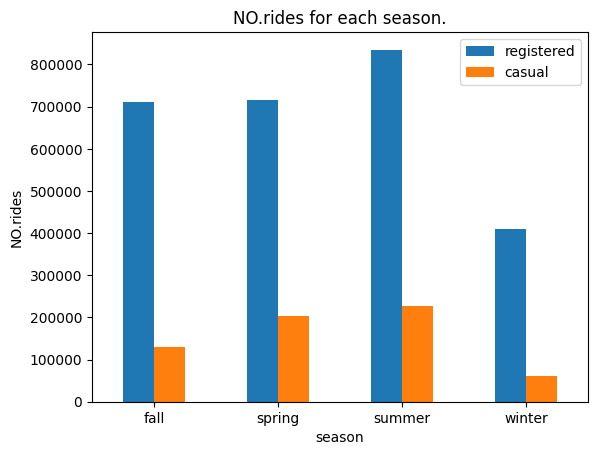

In [75]:
data = preprocessed_data[['season', 'registered', 'casual']]
plot_data = data.groupby('season').sum()
plot_data.plot(kind='bar', rot=0)
plt.ylabel('NO.rides')
plt.title('NO.rides for each season.')
plt.savefig('Figures/NO.rides for each season.png', format='png')